In [ ]:
import torch
import numpy as np
from PIL import Image
from typing import Union
from tqdm import tqdm
from pixel import (
    PyGameTextRenderer,
    AutoConfig,
    AutoModelForTokenClassification,
    PangoCairoBigramsRenderer,
    get_transforms,
    get_attention_mask,
    PIXELModel
)

from datasets import load_dataset
from scipy.stats import spearmanr

import seaborn as sns
import matplotlib.pyplot as plt

In [12]:
stsb = load_dataset("glue", "stsb")['train']

In [3]:
# PIXEL -- Continuous
pixel_cont_model_name = "Team-PIXEL/pixel-base"

px_cont_config = AutoConfig.from_pretrained(
    pixel_cont_model_name, 
    output_hidden_states=True)
pixel_cont = AutoModelForTokenClassification.from_pretrained(pixel_cont_model_name, config=px_cont_config)
pixel_cont = pixel_cont.eval()
pixel_cont.to('cuda') 

cont_renderer = PyGameTextRenderer.from_pretrained(
    pixel_cont_model_name,
    fallback_fonts_dir="../fonts/fonts",
    rgb=True,
    disable_fallback=False,   
)

Some weights of the model checkpoint at Team-PIXEL/pixel-base were not used when initializing PIXELForTokenClassification: ['decoder.decoder_layers.0.intermediate.dense.bias', 'decoder.decoder_layers.1.attention.output.dense.weight', 'decoder.decoder_layers.2.output.dense.bias', 'decoder.decoder_layers.3.output.dense.bias', 'decoder.decoder_layers.7.attention.output.dense.weight', 'decoder.decoder_layers.4.intermediate.dense.weight', 'decoder.decoder_layers.0.attention.attention.query.bias', 'decoder.decoder_layers.0.attention.output.dense.weight', 'decoder.decoder_layers.1.attention.attention.key.weight', 'decoder.decoder_layers.2.attention.output.dense.weight', 'decoder.decoder_layers.3.intermediate.dense.weight', 'decoder.decoder_layers.0.attention.output.dense.bias', 'decoder.decoder_layers.6.intermediate.dense.weight', 'decoder.decoder_layers.2.attention.attention.key.weight', 'decoder.decoder_layers.4.attention.attention.value.bias', 'decoder.decoder_layers.6.attention.attention.

In [4]:
# PIXEL -- bigrams
pixel_bigram_model_name = "Team-PIXEL/pixel-base-bigrams"

px_bigram_config = AutoConfig.from_pretrained(
    pixel_bigram_model_name, 
    output_hidden_states=True)
pixel_bigrams = AutoModelForTokenClassification.from_pretrained(pixel_bigram_model_name, config=px_bigram_config)
pixel_bigrams = pixel_bigrams.eval()
pixel_bigrams.to('cuda') 

bigrams_renderer = PangoCairoBigramsRenderer.from_pretrained(
    pixel_bigram_model_name,
    fallback_fonts_dir="../fonts/fonts",
    rgb=True,
    disable_fallback=False,   
)

Some weights of the model checkpoint at Team-PIXEL/pixel-base-bigrams were not used when initializing PIXELForTokenClassification: ['decoder.decoder_layers.0.intermediate.dense.bias', 'decoder.decoder_layers.1.attention.output.dense.weight', 'decoder.decoder_layers.2.output.dense.bias', 'decoder.decoder_layers.3.output.dense.bias', 'decoder.decoder_layers.7.attention.output.dense.weight', 'decoder.decoder_layers.4.intermediate.dense.weight', 'decoder.decoder_layers.0.attention.attention.query.bias', 'decoder.decoder_layers.0.attention.output.dense.weight', 'decoder.decoder_layers.1.attention.attention.key.weight', 'decoder.decoder_layers.2.attention.output.dense.weight', 'decoder.decoder_layers.3.intermediate.dense.weight', 'decoder.decoder_layers.0.attention.output.dense.bias', 'decoder.decoder_layers.6.intermediate.dense.weight', 'decoder.decoder_layers.2.attention.attention.key.weight', 'decoder.decoder_layers.4.attention.attention.value.bias', 'decoder.decoder_layers.6.attention.at

In [5]:
def get_preprocess_fn(
    processor:Union[PangoCairoBigramsRenderer, PyGameTextRenderer]
):
    transforms = get_transforms(
        do_resize=True,
        size=(processor.pixels_per_patch, processor.pixels_per_patch * processor.max_seq_length),
    )
    def image_preprocess_fn(example):
        encodings = processor(text=example)
        out = {}

        out["pixel_values"] = transforms(Image.fromarray(encodings.pixel_values))
        out["attention_mask"] = get_attention_mask(encodings.num_text_patches, seq_length=processor.max_seq_length) 

        return out
    preprocess_fn = image_preprocess_fn
    return preprocess_fn


def preprocess_text(s: str) -> str:
    # no preprocessing 
    return s

def extract_mean_embedding(
    word:str, 
    renderer:Union[PyGameTextRenderer, PangoCairoBigramsRenderer], 
    model:PIXELModel, 
    model_name:str,
    layer:int,
    device:str='cuda'):
    
    if not isinstance(word, str):
        raise ValueError(f"{word=} has wrong format")
    
    preprocess_fn = get_preprocess_fn(processor=renderer)
    t1 = preprocess_text(word)
    x1 = preprocess_fn(t1)
    w1 = renderer(t1)
    if model_name == "Team-PIXEL/pixel-base-bigrams":
        s1, e1 = 0, w1.word_starts[-1]
    elif model_name == "Team-PIXEL/pixel-base":
        s1, e1 = 0, w1.sep_patches[0]
    else:
        raise ValueError(f"Unknown model name {model_name}")

    with torch.no_grad():
        hidden1 = model(
            x1['pixel_values'][None].to(device), 
            x1['attention_mask'][None].to(device),
        )['hidden_states']
    h1 = hidden1[layer].squeeze()[s1+1: e1+1] # +1 for CLS; e1 is first patch after word so no need to + 1 

    # *** mean pooling 
    hs1 = torch.sum(h1, dim=0) / h1.shape[0] 
    return hs1

In [ ]:
# Evaluate on STS-B

cos_sim = torch.nn.CosineSimilarity(dim=0)
cont_dict = {}
bigrams_dict = {}
bigrams_lower_dict = {}
for l in tqdm(list(range(13)), desc="Layers"):
    print(f"{l=}")
    
    # pixel-base-continuous        
    stsb_cont_cos_sim = [cos_sim(
        extract_mean_embedding(x1, cont_renderer, pixel_cont, pixel_cont_model_name, layer=l), 
        extract_mean_embedding(x2, cont_renderer, pixel_cont, pixel_cont_model_name, layer=l)) 
        for x1,x2 in zip(stsb['sentence1'], stsb['sentence2'])]
    
    # pixel-base-bigrams
    stsb_bigrams_cos_sim = [cos_sim(
        extract_mean_embedding(x1, bigrams_renderer, pixel_bigrams, pixel_bigram_model_name, layer=l), 
        extract_mean_embedding(x2, bigrams_renderer, pixel_bigrams, pixel_bigram_model_name, layer=l)) 
        for x1,x2 in zip(stsb['sentence1'], stsb['sentence2'])]
    
    # pixel-base-bigrams lower-case
    stsb_bigrams_lower_cos_sim = [cos_sim(
        extract_mean_embedding(' '.join(w.lower() for w in x1.split()), bigrams_renderer, pixel_bigrams, pixel_bigram_model_name, layer=l), 
        extract_mean_embedding(' '.join(w.lower() for w in x2.split()), bigrams_renderer, pixel_bigrams, pixel_bigram_model_name, layer=l)) 
        for x1,x2 in zip(stsb['sentence1'], stsb['sentence2'])]

    correlation_cont, p_value_cont = spearmanr([x.cpu().numpy() for x in stsb_cont_cos_sim], stsb['label'])
    correlation_bigrams, p_value_bigrams = spearmanr([x.cpu().numpy() for x in stsb_bigrams_cos_sim], stsb['label'])
    correlation_bigrams_lower, p_value_bigrams_lower = spearmanr([x.cpu().numpy() for x in stsb_bigrams_lower_cos_sim], stsb['label'])
    
    mean_stsb_cont_cos_sim = np.mean([x.cpu().numpy() for x in stsb_cont_cos_sim])
    mean_stsb_bigrams_cos_sim = np.mean([x.cpu().numpy() for x in stsb_bigrams_cos_sim])
    mean_stsb_bigrams_lower_cos_sim = np.mean([x.cpu().numpy() for x in stsb_bigrams_lower_cos_sim])
    
    cont_dict[l] = {
        'acc': float(correlation_cont),
        'avg_cos_sim': float(mean_stsb_cont_cos_sim)
    } 
    bigrams_dict[l] = { 
        'acc': float(correlation_bigrams),
        'avg_cos_sim': float(mean_stsb_bigrams_cos_sim)
    } 
    bigrams_lower_dict[l] = {
        'acc': float(correlation_bigrams_lower),
        'avg_cos_sim': float(mean_stsb_bigrams_lower_cos_sim)
    } 

    print(f"{np.mean([x.cpu().numpy() for x in stsb_cont_cos_sim])=}")
    print(f"{np.mean([x.cpu().numpy() for x in stsb_bigrams_cos_sim])=}")
    print(f"{np.mean([x.cpu().numpy() for x in stsb_bigrams_lower_cos_sim])=}")
    print(f"{correlation_cont=}")
    print(f"{correlation_bigrams=}")
    print(f"{correlation_bigrams_lower=}")
    print(f"{p_value_cont=}")
    print(f"{p_value_bigrams=}")
    print(f"{p_value_bigrams_lower=}")

print(
    cont_dict,
    bigrams_dict,
    bigrams_lower_dict
)

In [ ]:
# to save time
cont_dict = {0: {'acc': 0.16743459962992413, 'avg_cos_sim': 0.9902867078781128}, 1: {'acc': 0.1832550582933185, 'avg_cos_sim': 0.9910606145858765}, 2: {'acc': 0.228723114583052, 'avg_cos_sim': 0.9859859347343445}, 3: {'acc': 0.3162542561884024, 'avg_cos_sim': 0.984960675239563}, 4: {'acc': 0.38457047437513836, 'avg_cos_sim': 0.9842773079872131}, 5: {'acc': 0.4816392642606273, 'avg_cos_sim': 0.9807863235473633}, 6: {'acc': 0.5061323669252905, 'avg_cos_sim': 0.9748716354370117}, 7: {'acc': 0.5100201803003402, 'avg_cos_sim': 0.9668488502502441}, 8: {'acc': 0.4909428744222947, 'avg_cos_sim': 0.9562854766845703}, 9: {'acc': 0.4646786404486987, 'avg_cos_sim': 0.9396920204162598}, 10: {'acc': 0.43218350642580766, 'avg_cos_sim': 0.9233846068382263}, 11: {'acc': 0.41863653343617313, 'avg_cos_sim': 0.906975507736206}, 12: {'acc': 0.34070277588810627, 'avg_cos_sim': 0.9371498823165894}}
bigrams_dict = {0: {'acc': 0.21234713918006004, 'avg_cos_sim': 0.9959408640861511}, 1: {'acc': 0.19988781137628014, 'avg_cos_sim': 0.9961429238319397}, 2: {'acc': 0.3206174575298661, 'avg_cos_sim': 0.9952228665351868}, 3: {'acc': 0.43808706063638003, 'avg_cos_sim': 0.9936881065368652}, 4: {'acc': 0.5113543330367949, 'avg_cos_sim': 0.9904981851577759}, 5: {'acc': 0.5310880629489491, 'avg_cos_sim': 0.9877057671546936}, 6: {'acc': 0.5459756144123754, 'avg_cos_sim': 0.9805892705917358}, 7: {'acc': 0.5466751007764402, 'avg_cos_sim': 0.9715167284011841}, 8: {'acc': 0.5284581025779411, 'avg_cos_sim': 0.9547395706176758}, 9: {'acc': 0.4998336655844785, 'avg_cos_sim': 0.937190055847168}, 10: {'acc': 0.49047717118572415, 'avg_cos_sim': 0.9103521108627319}, 11: {'acc': 0.4749650094599774, 'avg_cos_sim': 0.9001320004463196}, 12: {'acc': 0.4493262095065831, 'avg_cos_sim': 0.9330413341522217}}
bigrams_lower_dict = {0: {'acc': 0.21685156472740708, 'avg_cos_sim': 0.9959720969200134}, 1: {'acc': 0.20378404367135744, 'avg_cos_sim': 0.9962612986564636}, 2: {'acc': 0.3316534406522692, 'avg_cos_sim': 0.9954414367675781}, 3: {'acc': 0.45826099650582136, 'avg_cos_sim': 0.9939773082733154}, 4: {'acc': 0.532484747185733, 'avg_cos_sim': 0.9907758235931396}, 5: {'acc': 0.5535695523899902, 'avg_cos_sim': 0.9880245923995972}, 6: {'acc': 0.5754913603045223, 'avg_cos_sim': 0.9813549518585205}, 7: {'acc': 0.5773690859299554, 'avg_cos_sim': 0.9725947380065918}, 8: {'acc': 0.5618306021475246, 'avg_cos_sim': 0.956406831741333}, 9: {'acc': 0.5360918440478607, 'avg_cos_sim': 0.939742386341095}, 10: {'acc': 0.523844901455791, 'avg_cos_sim': 0.9130869507789612}, 11: {'acc': 0.5085198263092846, 'avg_cos_sim': 0.9035497903823853}, 12: {'acc': 0.48490276454922654, 'avg_cos_sim': 0.9346321225166321}}

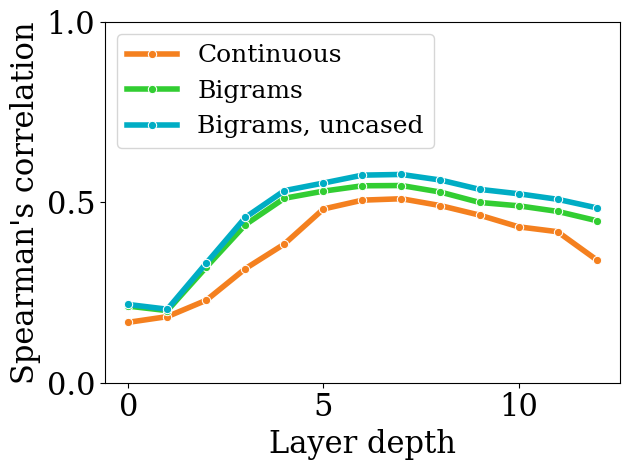

In [11]:
SIZE = 22
custom_palette=["#F4801F", "#32CD32", "#00ADC4", "#41157A", "#CC1E4A",]
sns.set_style({'font.family':'serif', 'font.serif':'Times New Roman'})

fig, axs = plt.subplots()

# Create x values corresponding to your arrays.
x = list(range(13))

# Create the plot
sns.lineplot(x=x, y=[cont_dict[l]['acc'] for l in list(range(13))], color=custom_palette[0], linewidth=4, label="Continuous", marker='o')
sns.lineplot(x=x, y=[bigrams_dict[l]['acc'] for l in list(range(13))], color=custom_palette[1], linewidth=4, label="Bigrams",  marker='o')
sns.lineplot(x=x, y=[bigrams_lower_dict[l]['acc'] for l in list(range(13))], color=custom_palette[2], linewidth=4, label="Bigrams, uncased", marker='o')
plt.legend(loc="upper left", title='', fontsize=SIZE-4, title_fontsize=SIZE, frameon=True)


# Set y-axis label
plt.ylabel("Spearman's correlation", fontsize=SIZE)
plt.xticks([0, 5,10], fontsize=SIZE)  # x is the array of x values
# plt.grid(alpha=0.2)
plt.yticks([0.0, 0.5, 1.0], fontsize=SIZE)
# Set x-axis label
plt.xlabel('Layer depth', fontsize=SIZE)
plt.tight_layout()
plt.savefig("output/stsb-corr-acc.pdf", dpi=500)
plt.show()
